In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Лучшее k для KNN: 11 с точностью 0.7541

--- Метрики для Naive Bayes ---
Accuracy:  0.8689
Precision: 0.9000
Recall:    0.8438
F1-score:  0.8710


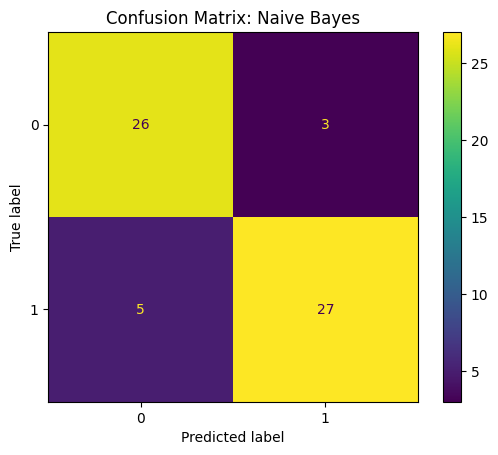


--- Метрики для Logistic Regression ---
Accuracy:  0.8852
Precision: 0.8788
Recall:    0.9062
F1-score:  0.8923


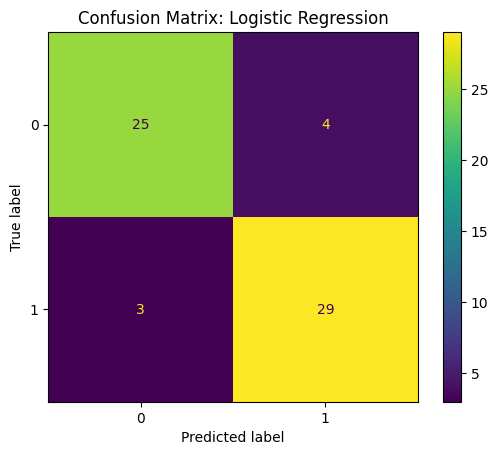


--- Метрики для KNN (k=11) ---
Accuracy:  0.7541
Precision: 0.7429
Recall:    0.8125
F1-score:  0.7761


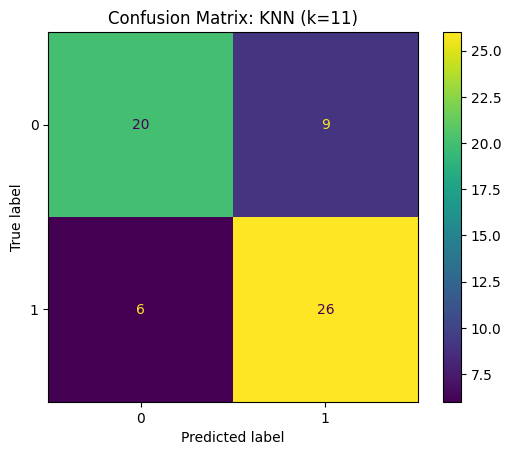

In [18]:
folder_path ='/content/drive/MyDrive/Data Science/datasets/'
file_path=folder_path+'heart.csv'
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import StandardScaler


df = pd.read_csv(file_path)

# разделяем на x и y
X = df.drop('target', axis=1) # Предположим, колонка называется 'target'
y = df['target']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Масштабируем
scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)


from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# А. Наивный Байес
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Б. Логистическая регрессия
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

# В. k-ближайших соседей (поиск лучшего k)
best_k = 1
best_acc = 0
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    if acc > best_acc:
        best_acc = acc
        best_k = k

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

print(f"Лучшее k для KNN: {best_k} с точностью {best_acc:.4f}")

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n--- Метрики для {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

# Запускаем оценку для всех
evaluate_model(nb_model, X_test, y_test, "Naive Bayes")
evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
evaluate_model(knn_model, X_test, y_test, f"KNN (k={best_k})")


In [30]:
def get_metrics(model, X_test, y_test, name):
   y_pred = model.predict(X_test)
   return {
        'Модель': name,
        'Wromg prediction' : (y_test != y_pred).sum(),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-score': round(f1_score(y_test, y_pred), 4)
    }


results_list = [
    get_metrics(nb_model, X_test, y_test, "Naive Bayes"),
    get_metrics(lr_model, X_test,y_test, "Logistic Regression"),
    get_metrics(knn_model, X_test,y_test, f"KNN (k={best_k})") ]

results_df = pd.DataFrame(results_list)

display(results_df) #

,Модель,Wromg prediction,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,8,0.8689,0.9000,0.8438,0.8710
1,Logistic Regression,7,0.8852,0.8788,0.9062,0.8923
2,KNN (k=11),15,0.7541,0.7429,0.8125,0.7761


In [14]:
def get_metrics(model, X_test, y_test, name):
   y_pred = model.predict(X_test)
   return {
        'Модель': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-score': round(f1_score(y_test, y_pred), 4)
    }


results_list = [
    get_metrics(nb_model, X_test, y_test, "Naive Bayes"),
    get_metrics(lr_model, X_test,y_test, "Logistic Regression"),
    get_metrics(knn_model, X_test,y_test, f"KNN (k={best_k})") ]

results_df = pd.DataFrame(results_list)

display(results_df) #

,Модель,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,0.8689,0.9000,0.8438,0.8710
1,Logistic Regression,0.8525,0.8710,0.8438,0.8571
2,KNN (k=7),0.9180,0.9355,0.9062,0.9206


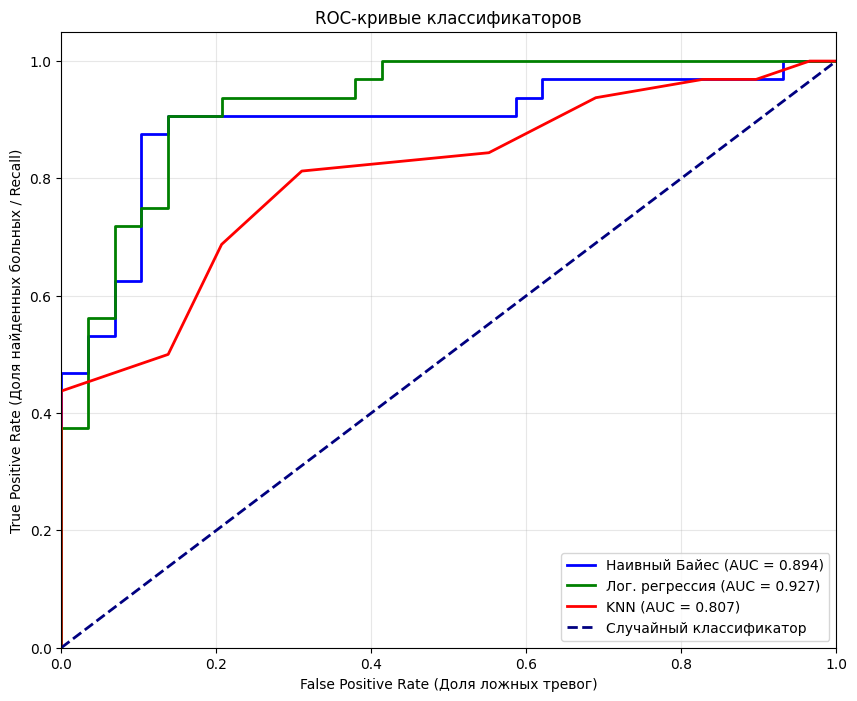

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# --- 1. Наивный Байес ---
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Наивный Байес (AUC = {auc_nb:.3f})')

# --- 2. Логистическая регрессия ---
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Лог. регрессия (AUC = {auc_lr:.3f})')

# --- 3. KNN ---
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, color='red', lw=2, label=f'KNN (AUC = {auc_knn:.3f})')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Доля ложных тревог)')
plt.ylabel('True Positive Rate (Доля найденных больных / Recall)')
plt.title('ROC-кривые классификаторов')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1VVNE_EEKtDQ9vGnII_8V8KyaiUJMGd-6wb3GttzPHEA/edit#gid=0
